In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/titanic_data_updated.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
print(f"Total potential features : {df.shape[1]}")
print(f"Total sample data : {df.shape[0]}")

Total potential features : 12
Total sample data : 891


In [6]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
233,234,yes,third,"Asplund, Miss. Lillian Gertrud",female,5.0,4,2,347077,31.3875,NaN,S
44,45,yes,third,"Devaney, Miss. Margaret Delia",female,19.0,0,0,330958,7.8792,NaN,Q
883,884,no,second,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
720,721,yes,second,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
401,402,no,third,"Adams, Mr. John",male,26.0,0,0,341826,8.0500,NaN,S
16,17,no,third,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
824,825,no,third,"Panula, Master. Urho Abraham",male,2.0,4,1,3101295,39.6875,NaN,S
18,19,no,third,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
537,538,yes,first,"LeRoy, Miss. Bertha",female,30.0,0,0,PC 17761,106.4250,NaN,C
570,571,yes,second,"Harris, Mr. George",male,62.0,0,0,S.W./PP 752,10.5000,NaN,S


In [8]:
# Missing Values :

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
# Checking Duplicates :

df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [11]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


# Univariate Analysis ( Categorical Values )

<Axes: xlabel='Survived', ylabel='count'>

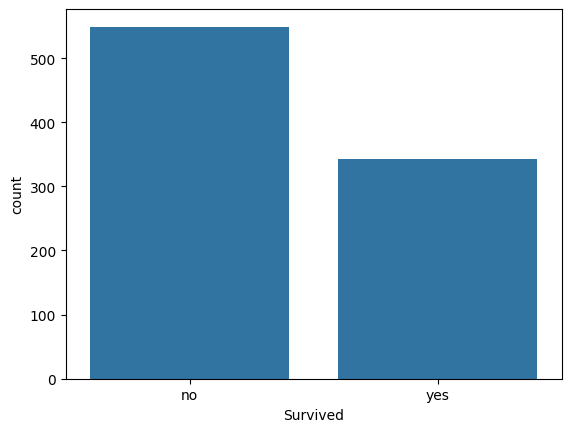

In [12]:
sns.countplot(
    data=df,
    x='Survived'
)

In [13]:
df['Survived'].value_counts() / len(df) * 100

,count
Survived,
no,61.616162
yes,38.383838


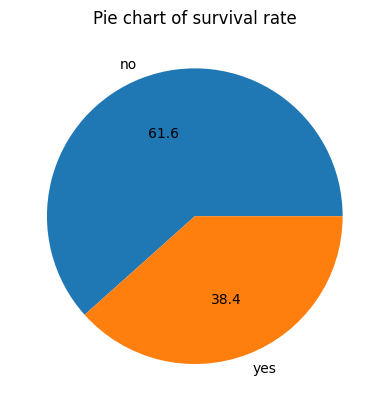

In [14]:
survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()

plt.pie(survived_count,labels=survived_label, autopct="%1.1f")
plt.title("Pie chart of survival rate")
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

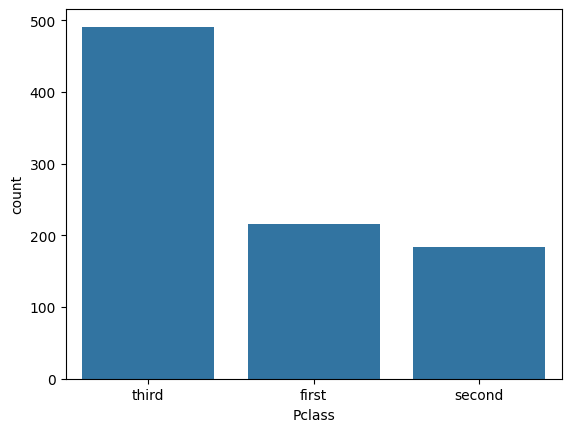

In [15]:
sns.countplot(
    data=df,
    x='Pclass'
)

In [16]:
df['Pclass'].value_counts() / len(df) * 100

,count
Pclass,
third,55.106622
first,24.242424
second,20.650954


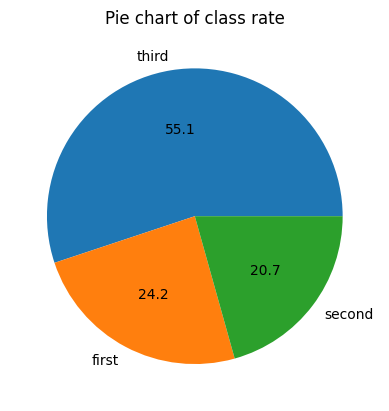

In [17]:
survived_count = df['Pclass'].value_counts()
survived_label = df['Pclass'].unique()

plt.pie(survived_count,labels=survived_label, autopct="%1.1f")
plt.title("Pie chart of class rate")
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

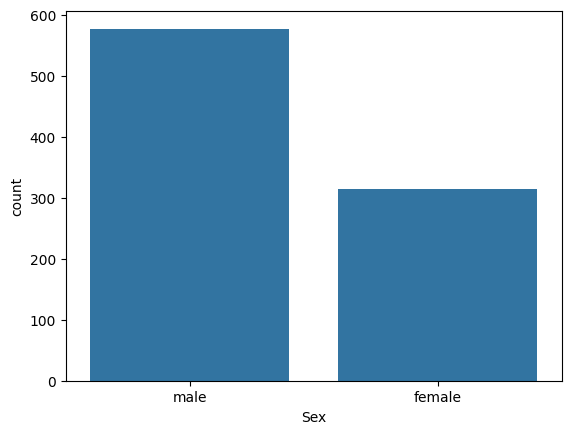

In [18]:
sns.countplot(
    data=df,
    x='Sex'
)

In [19]:
df['Sex'].value_counts() / len(df) * 100

,count
Sex,
male,64.758698
female,35.241302


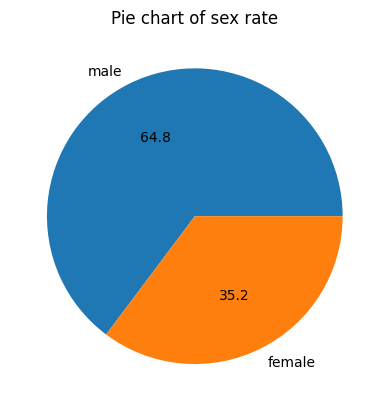

In [20]:
count = df['Sex'].value_counts()
label = df['Sex'].unique()

plt.pie(count,labels=label, autopct="%1.1f")
plt.title("Pie chart of sex rate")
plt.show()

<Axes: xlabel='Embarked', ylabel='count'>

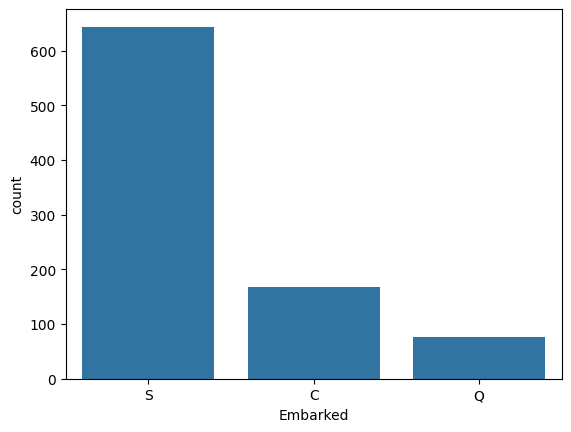

In [21]:
sns.countplot(
    data=df,
    x='Embarked'
)

In [22]:
df['Embarked'].value_counts() / len(df) * 100

,count
Embarked,
S,72.278339
C,18.855219
Q,8.641975


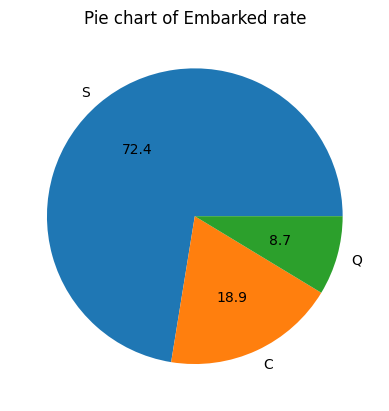

In [23]:
count = df['Embarked'].value_counts()
label = df['Embarked'].unique()[:-1]


plt.pie(count,labels=label, autopct="%1.1f")
plt.title("Pie chart of Embarked rate")
plt.show()

# Univariate Analysis ( Numerical Values )

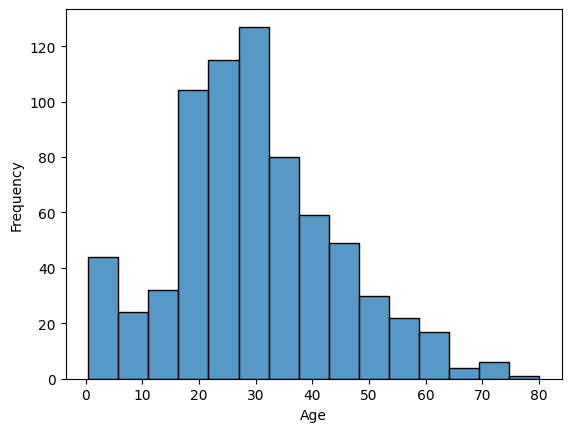

In [29]:
sns.histplot(
    data=df,
    x='Age',
    bins=15
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

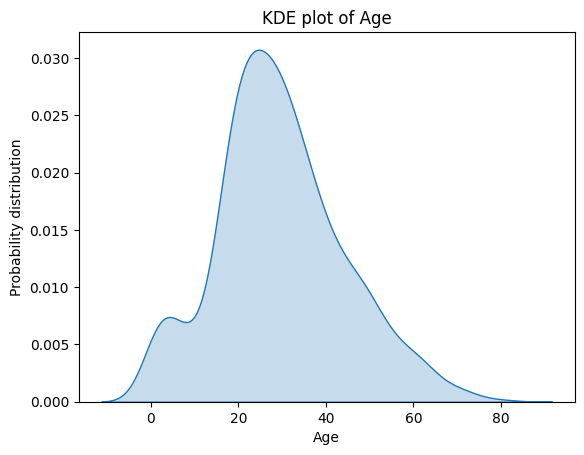

In [32]:
sns.kdeplot(
    data=df,
    x='Age',
    fill=True
)

plt.title("KDE plot of Age")
plt.xlabel("Age")
plt.ylabel("Probability distribution")
plt.show()

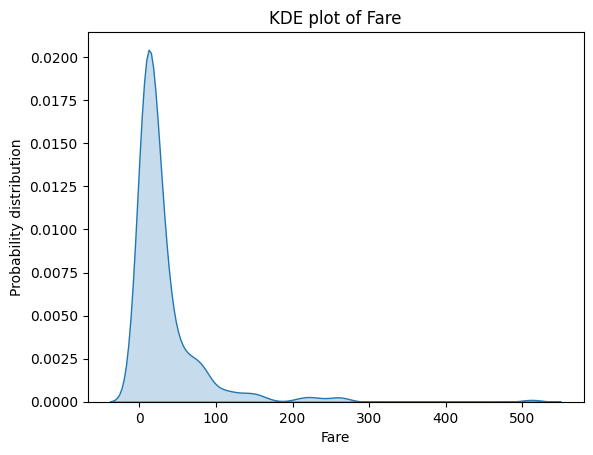

In [33]:
sns.kdeplot(
    data=df,
    x='Fare',
    fill=True
)

plt.title("KDE plot of Fare")
plt.xlabel("Fare")
plt.ylabel("Probability distribution")
plt.show()

<Axes: ylabel='Fare'>

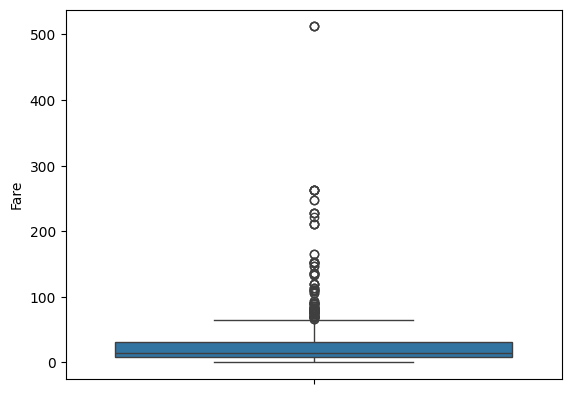

In [43]:
sns.boxplot(df['Fare'])